In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [39]:
def load_yield_data():

    yield_data = pd.read_csv('data/EU_yield_curves_combined.csv')

    expected_columns = ['EU_1Y', 'EU_5Y', 'EU_10Y', 'EU_20Y', 'EU_30Y']

    if not all(col in yield_data.columns for col in expected_columns):
        raise ValueError('The expected columns do not exist in the dataframe')

    yield_data['DATE'] = pd.to_datetime(yield_data['DATE'])
    yield_data.set_index('DATE', inplace = True)

    return yield_data

yield_data = load_yield_data()

In [40]:
# Check for missing values
print('Missing values in each column:')
print(yield_data.isna().sum())

Missing values in each column:
EU_1Y     0
EU_5Y     0
EU_10Y    0
EU_20Y    0
EU_30Y    0
dtype: int64


In [41]:
# Check for zero variance
print('Variance of each column:')
print(yield_data.var())

Variance of each column:
EU_1Y     2.680141
EU_5Y     2.481493
EU_10Y    2.481108
EU_20Y    2.418795
EU_30Y    2.272659
dtype: float64


In [42]:
print('Condition number of the data matrix:')
condition_number = np.linalg.cond(yield_data[['EU_1Y', 'EU_5Y', 'EU_10Y', 'EU_20Y', 'EU_30Y']])
print(round(condition_number, 2))

Condition number of the data matrix:
176.77


In [43]:
def load_economic_data():
    ...

econ_data = load_economic_data()

In [44]:
def calculate_curve_measure(df: pd.DataFrame):

     measures = pd.DataFrame(index = df.index)

     measures['Level'] = df['EU_10Y']

     # Slope measures
     measures['Slope_1s10s'] = df['EU_10Y'] - df['EU_1Y']
     measures['Slope_5s30s'] = df['EU_30Y'] - df['EU_5Y']

     measures['Butterfly_5s'] = df['EU_5Y'] - 0.5 * (df['EU_1Y'] + df['EU_10Y'])
     measures['Butterfly_10s'] = df['EU_10Y'] - 0.5 * (df['EU_5Y'] + df['EU_20Y'])
     measures['Butterfly_20s'] = df['EU_20Y'] - 0.5 * (df['EU_10Y'] + df['EU_30Y'])

     return measures

curve_measures = calculate_curve_measure(yield_data)

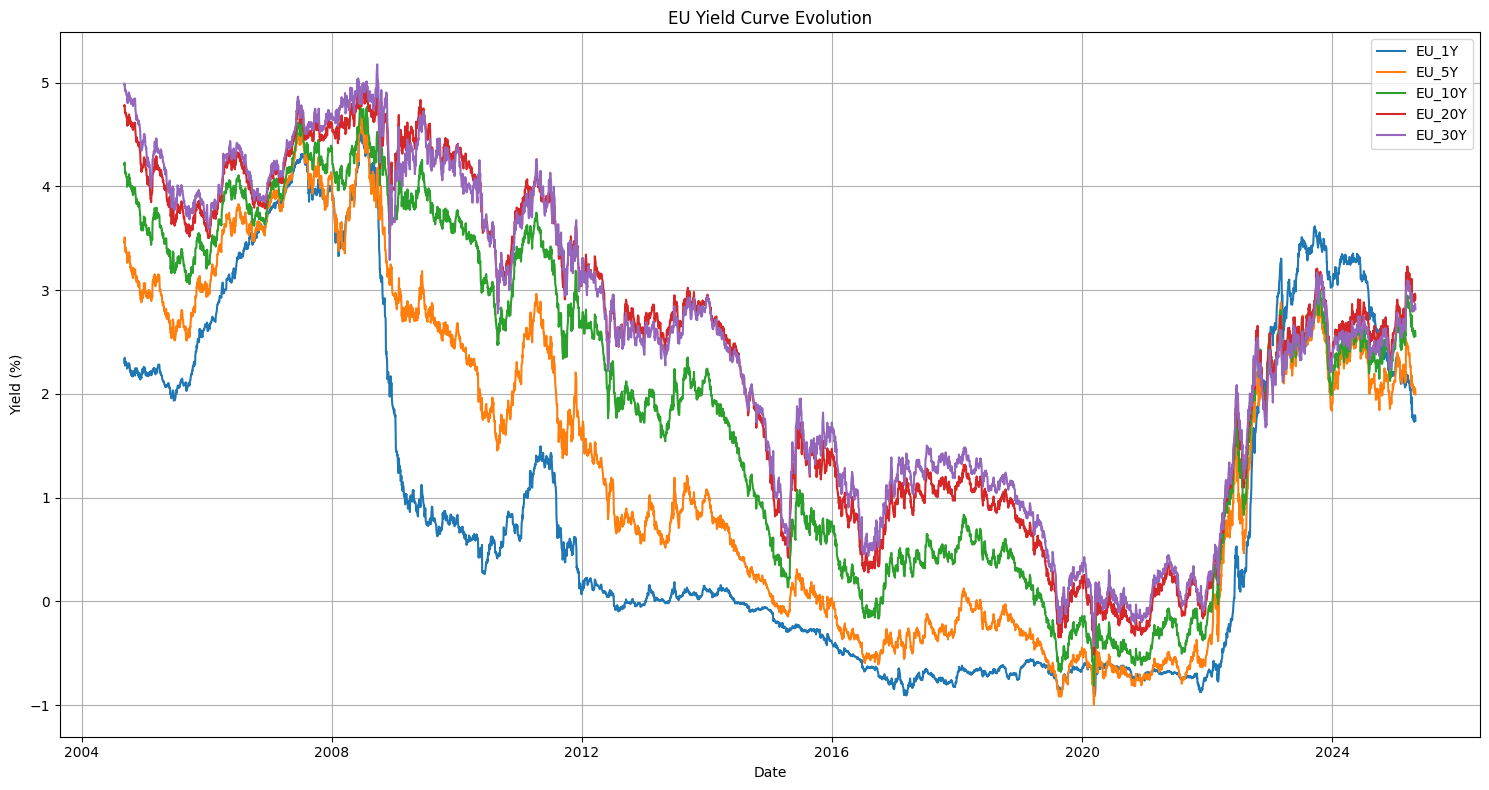

In [45]:
# Plot yield curve over time
plt.figure(figsize = (15,8))
for col in yield_data.columns:
    plt.plot(yield_data.index, yield_data[col], label=col)
plt.title('EU Yield Curve Evolution')
plt.xlabel('Date')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('images/yield_curve_evolution.png')
plt.show()

In [51]:
def perform_yield_pca(yield_df: pd.DataFrame, n_components: int = 3):

    pca_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components)),
    ])

    components = pca_pipeline.fit_transform(yield_df)

    pca_df = pd.DataFrame(components,
                          index = yield_data.index,
                          columns = [f'PC{i + 1}' for i in range(n_components)]
                          )

    pca_model = pca_pipeline.named_steps['pca']

    explained_variance = pca_model.explained_variance_ratio_

    return pca_df, explained_variance, pca_model, pca_pipeline

In [52]:
yield_pca_df, yield_exp_variance, yield_pca_model, pca_pipeline = perform_yield_pca(yield_data)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


In [53]:
print("Yield PCA Explained Variance Ratio")
for i, var in enumerate(yield_exp_variance):
    print(f'PC{i + 1}: {var:.4f} ({var*100:.2f})')

Yield PCA Explained Variance Ratio
PC1: 0.9283 (92.83)
PC2: 0.0678 (6.78)
PC3: 0.0030 (0.30)


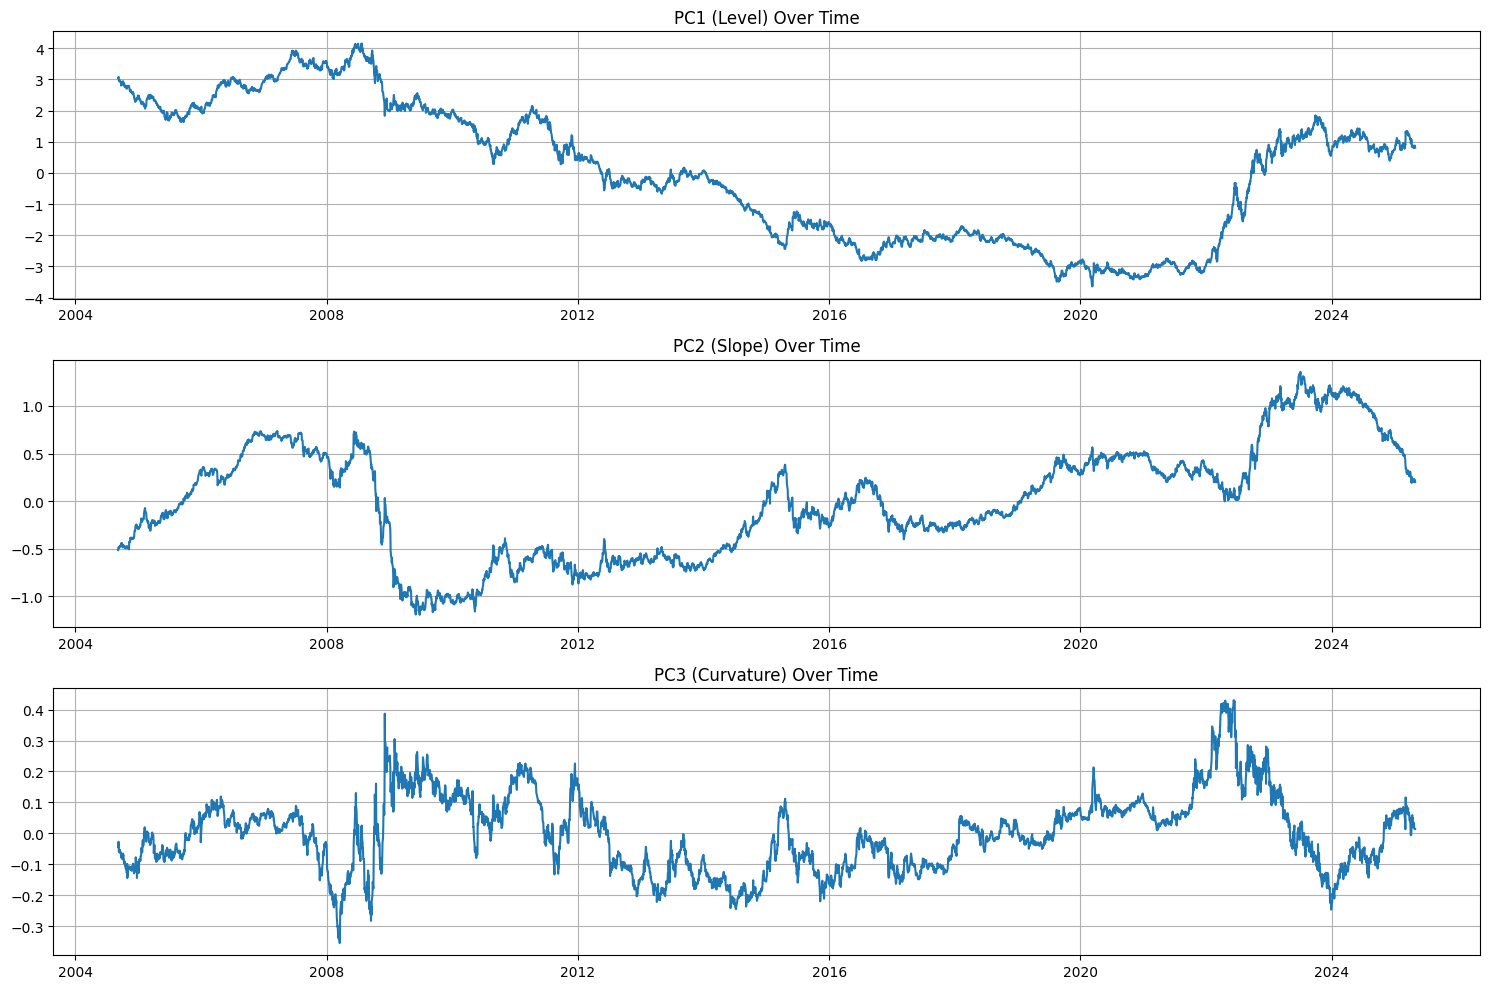

In [54]:
plt.figure(figsize=(15,10))

plt.subplot(3,1,1)
plt.plot(yield_pca_df['PC1'])
plt.title('PC1 (Level) Over Time')
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(yield_pca_df['PC2'])
plt.title('PC2 (Slope) Over Time')
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(yield_pca_df['PC3'])
plt.title('PC3 (Curvature) Over Time')
plt.grid(True)

plt.tight_layout()
plt.savefig('images/yield_pca_components.png')

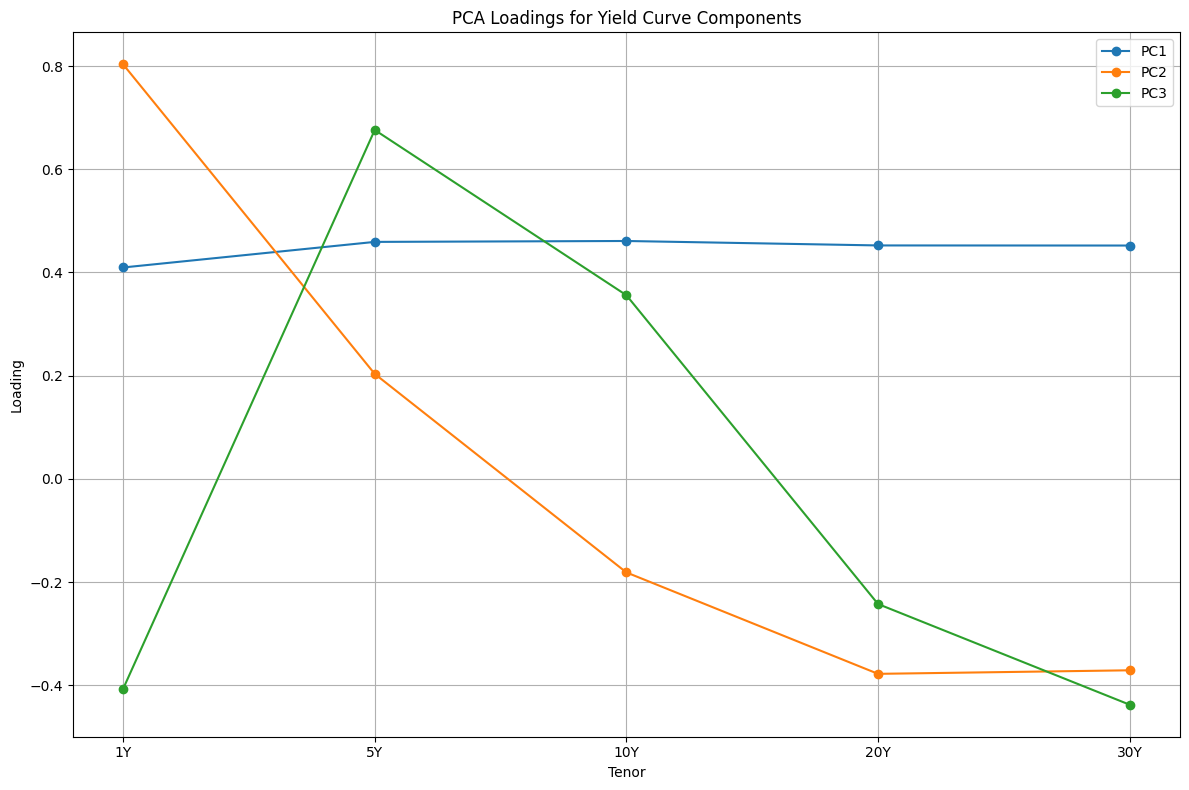

In [55]:
# Plot PCA loadings
plt.figure(figsize=(12,8))
loadings = yield_pca_model.components_
tenors = ['1Y', '5Y', '10Y', '20Y', '30Y']

for i, loading in enumerate(loadings):
    plt.plot(tenors, loading, marker='o', label = f'PC{i + 1}')

plt.xlabel('Tenor')
plt.ylabel('Loading')
plt.title('PCA Loadings for Yield Curve Components')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('images/pca_loadings.png')
plt.show()

In [56]:
def reconstruct_yield_curve(pca_pipeline, pca_components, original_data):

    pca_model = pca_pipeline.named_steps['pca']
    scaler = pca_pipeline.named_steps['scaler']

    limited_components = pca_components.copy()

    reconstructed_scaled = pca_model.inverse_transform(limited_components)
    reconstructed = scaler.inverse_transform(reconstructed_scaled)

    reconstructed_df = pd.DataFrame(
        reconstructed,
        index = original_data.index,
        columns = original_data.columns
    )

    return reconstructed_df

reconstructed_yields = reconstruct_yield_curve(
    pca_pipeline,
    yield_pca_df[['PC1', 'PC2', 'PC3']].values,
    yield_data
)

residuals = yield_data - reconstructed_yields

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:197: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.components_ + self.mean_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:197: RuntimeWarning: overflow encountered in matmul
  return X @ self.components_ + self.mean_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:197: RuntimeWarning: invalid value encountered in matmul
  return X @ self.components_ + self.mean_


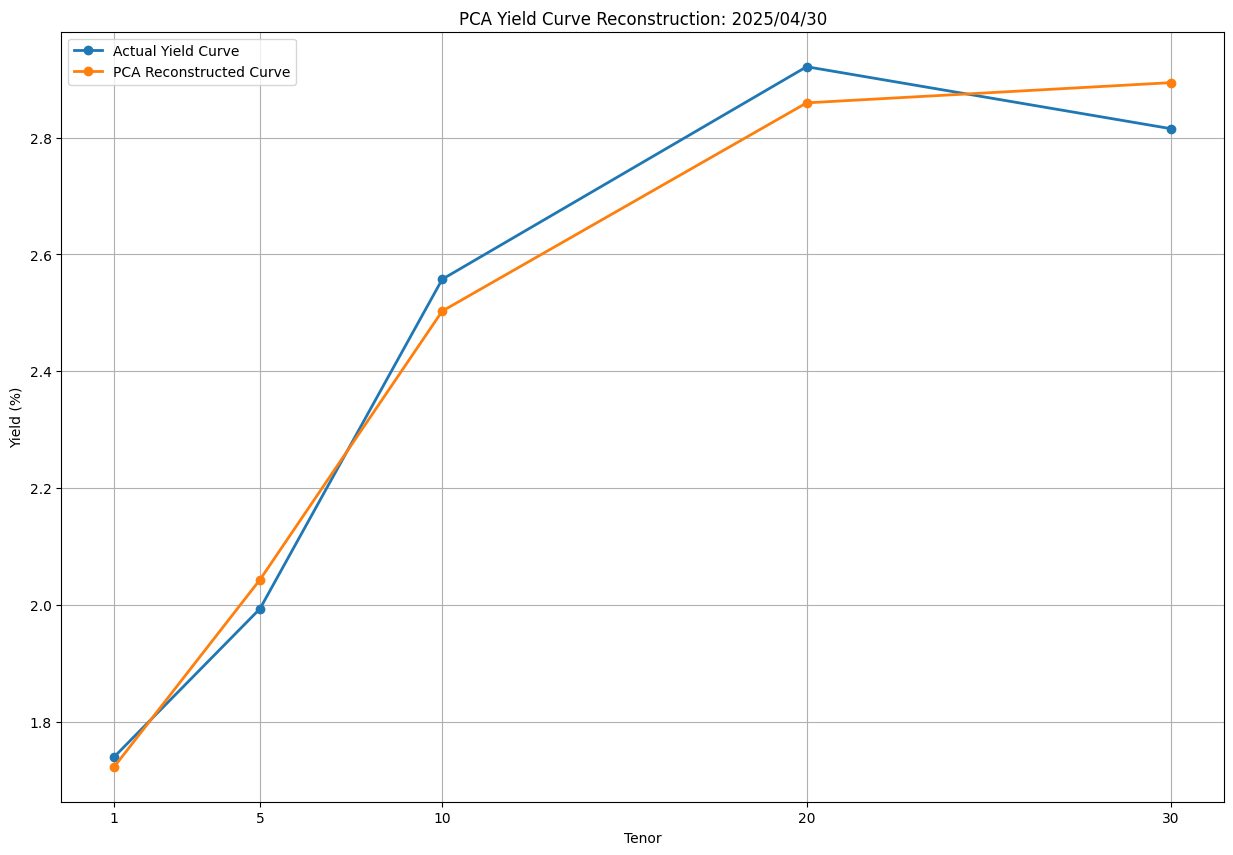


Differences (Actual - Reconstructed):
1Y: 0.0169%
5Y: -0.0498%
10Y: 0.0545%
20Y: 0.0618%
30Y: -0.0789%


In [61]:
def plot_yield_curve_with_reconstruction(actual_data, reconstructed_data, date_idx:int = -1):

    date = actual_data.index[date_idx]

    plt.figure(figsize=(15,10))

    tenors = [1, 5, 10, 20, 30]

    actual = actual_data.iloc[date_idx].values
    reconstructed = reconstructed_data.iloc[date_idx].values

    plt.plot(tenors, actual, label='Actual Yield Curve', marker='o', linewidth = 2)
    plt.plot(tenors, reconstructed, label='PCA Reconstructed Curve', marker='o', linewidth = 2)

    plt.xlabel('Tenor')
    plt.ylabel('Yield (%)')
    plt.title(f'PCA Yield Curve Reconstruction: {date.strftime("%Y/%m/%d")}')
    plt.legend()
    plt.grid(True)
    plt.xticks(tenors)
    plt.savefig('images/yield_curve_reconstruction.png')
    plt.show()

    diff = actual - reconstructed
    print('\nDifferences (Actual - Reconstructed):')
    for i, tenor in enumerate(tenors):
        print(f'{tenor}Y: {diff[i]:.4f}%')

plot_yield_curve_with_reconstruction(
    yield_data,
    reconstructed_yields
)

In [63]:
def calculate_standard_deviation(actual_data, reconstructed_data, window: int = 252):

    residuals = actual_data - reconstructed_data

    z_scores = pd.DataFrame(
        index = residuals.index,
        columns = residuals.columns
    )

    rolling_std = residuals.rolling(window).std()

    for col in residuals.columns:
        z_scores[col] = residuals[col] / rolling_std[col].replace(0, np.nan)

    return z_scores

standardized_deviations = calculate_standard_deviation(
    yield_data,
    reconstructed_yields)

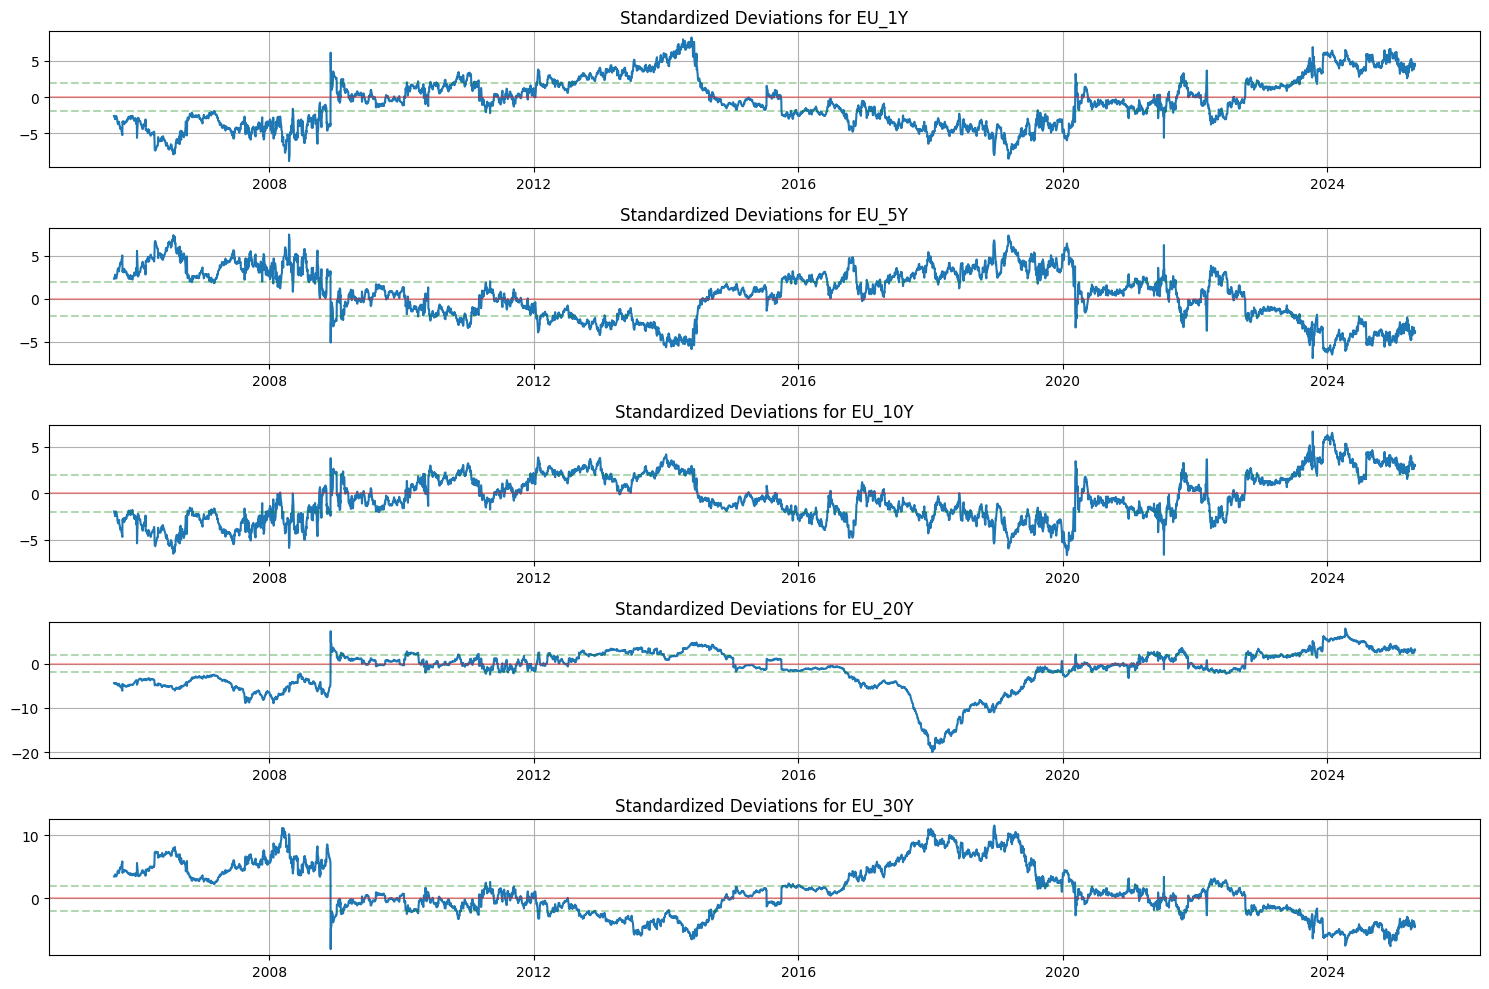

In [64]:
# Plot deviations
plt.figure(figsize=(15,10))

for i, col in enumerate(standardized_deviations.columns):
    plt.subplot(len(standardized_deviations.columns), 1, i + 1)
    plt.plot(standardized_deviations.index, standardized_deviations[col])
    plt.title(f'Standardized Deviations for {col}')
    plt.grid(True)
    plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
    plt.axhline(y=2, color='g', linestyle='--', alpha=0.3)
    plt.axhline(y=-2, color='g', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('images/standardized_deviations.png')
plt.show()

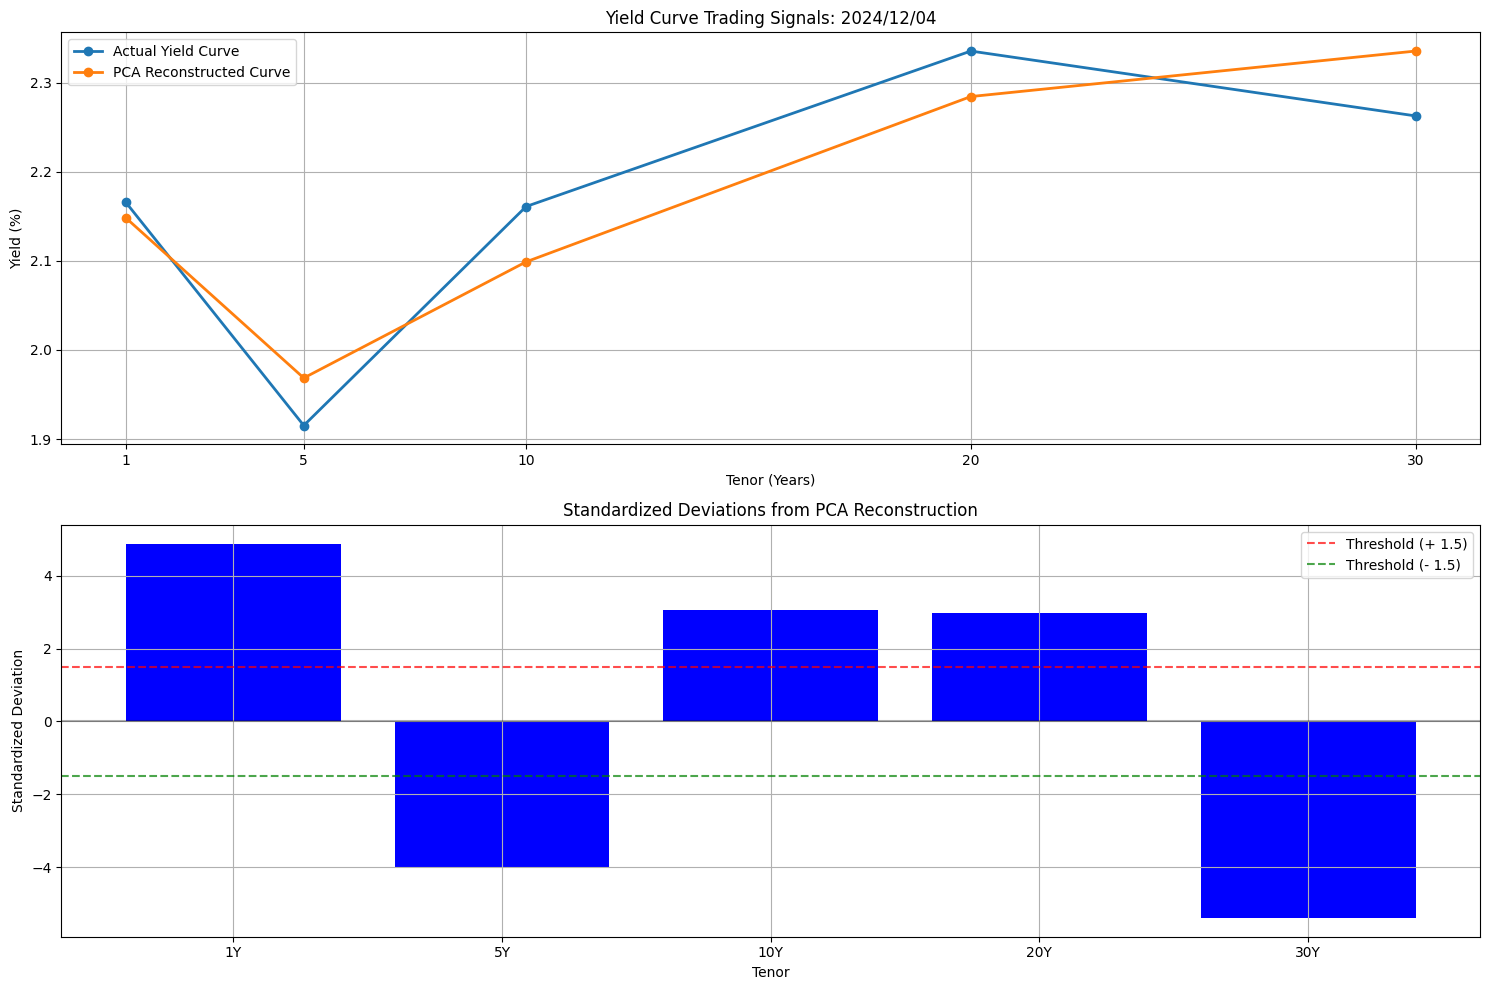

In [65]:
def plot_trading_signal_example(std_devs, actual_data, date_index:int = -100, threshold = 1.5):

    date = std_devs.index[date_index]

    deviations = std_devs.iloc[date_index]

    # Determine signals based on threshold
    signals = deviations.copy()
    signals[signals > threshold] = -1 # Sell signal when rich
    signals[signals < -threshold] = 1 # Buy signal when cheap
    signals[(signals >= -threshold) & (signals <= threshold)] = 0 # No signal

    plt.figure(figsize=(15,10))

    plt.subplot(2,1,1)
    tenors = [1, 5, 10, 20, 30]
    actual = actual_data.iloc[date_index].values

    reconstructed = reconstructed_yields.iloc[date_index].values

    plt.plot(tenors, actual, marker =  'o', label='Actual Yield Curve', linewidth = 2)
    plt.plot(tenors, reconstructed, label='PCA Reconstructed Curve', marker = 'o', linewidth = 2)

    # Highlight oportunities
    for i, tenor in enumerate(tenors):
        if signals.iloc[i] == 1:
            plt.scatter([tenor], [actual[i]], color = 'green', s = 150, zorder = 5,
                        label = 'Buy (Cheap)' if 'Buy' not in plt.gca().get_legend_handles_labels()[1] else "")
        elif signals.iloc[i] == -1:
            plt.scatter([tenor], [actual[i]], color = 'red', s = 150, zorder = 5,
                        label = 'Sell (Rich)' if 'Sell' not in plt.gca().get_legend_handles_labels()[1] else "")

    plt.xlabel('Tenor (Years)')
    plt.ylabel('Yield (%)')
    plt.title(f'Yield Curve Trading Signals: {date.strftime("%Y/%m/%d")}')
    plt.legend()
    plt.grid(True)
    plt.xticks(tenors)

    plt.subplot(2,1,2)
    plt.bar(range(len(deviations)), deviations, color = ['green' if x == 1 else 'red' if x == -1 else 'blue' for x in signals])

    plt.axhline(y=threshold, color='r', linestyle='--', alpha=0.7, label=f'Threshold (+ {threshold})')
    plt.axhline(y=-threshold, color='g', linestyle='--', alpha=0.7, label=f'Threshold (- {threshold})')
    plt.axhline(y = 0, color='k', linestyle='-', alpha=0.3)

    plt.xlabel('Tenor')
    plt.ylabel('Standardized Deviation')
    plt.title('Standardized Deviations from PCA Reconstruction')
    plt.xticks(range(len(deviations)), [col.replace('EU_', '') for col in actual_data.columns])
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('images/trading_signal_example.png')
    plt.show()

plot_trading_signal_example(standardized_deviations, yield_data)